# Entrenamiento de Modelos — MFCC con Datos Aumentados

En este notebook seguimos la misma estructura que en `ModelosPreprocesamientoChunkedMFCC`, pero trabajando sobre el **dataset aumentado**. El data augmentation es una técnica habitual en machine learning que consiste en generar nuevas muestras de entrenamiento aplicando transformaciones a las muestras originales, con el objetivo de aumentar la variedad del conjunto de entrenamiento sin necesidad de recopilar nuevos datos.

En nuestro caso, se aplicaron tres técnicas de augmentation sobre cada chunk de entrenamiento:

1. **Ruido gaussiano** — simula variaciones del entorno clínico (ruido de equipos, interferencias de sala).
2. **Pitch shift (+2 semitonos)** — simula variaciones en la fisiología vocal del paciente.
3. **Time stretch (×1.15)** — simula taquipnea leve (respiración un 15% más rápida).

Como resultado, el conjunto de entrenamiento pasa de **1074 a 4296 muestras** (×4), mientras que el conjunto de test se mantiene en **247 muestras originales**, ya que el test nunca se aumenta: debe representar condiciones reales de inferencia.

Esta expansión mejora notablemente la relación muestras/características, reduciendo el riesgo de sobreajuste:

| Representación | Nº características | Ratio (aumentado) | Ratio (original) |
|---|---|---|---|
| Flat + PCA (≈171) | ~171 | 4296/171 ≈ **25:1** | 1074/171 ≈ 6:1 |
| Flat + SelectKBest (75) | 75 | 4296/75 ≈ **57:1** | 1074/75 ≈ 14:1 |
| Pool (≈60) | ~60 | 4296/60 ≈ **72:1** | 1074/60 ≈ 18:1 |

Sin embargo, hay que tener en cuenta que las muestras aumentadas **no son independientes**: todas derivan de las mismas 56 grabaciones originales, por lo que el límite real de información del dataset no varía. El objetivo sigue siendo el mismo: demostrar empíricamente el rendimiento del baseline con MFCC chunkeados, ahora con el beneficio del data augmentation.

In [52]:
import pickle
import numpy as np
import pandas as pd
import mlflow

#Tablas y Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

#Preprocesado
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

#Modelos
import joblib
from sklearn.base import clone
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc, classification_report
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import PredefinedSplit
from lightgbm import LGBMClassifier

In [2]:
mlflow.set_tracking_uri("sqlite:///../resultados/resultados_voces.db")
mlflow.set_experiment("Clasificacion_Modelos_Clasicos_Notebooks")

<Experiment: artifact_location='file:///C:/Users/pedro/git/RepositorioInvestigacionTFG/notebooks/mlruns/3', creation_time=1781536250318, effective_trace_archival_retention=None, experiment_id='3', last_update_time=1781536250318, lifecycle_stage='active', name='Clasificacion_Modelos_Clasicos_Notebooks', tags={}, trace_location=None, workspace='default'>

In [3]:
ruta_train = '../datos_entrenamiento/train_mfcc_chunked_aumentado.pkl'
ruta_test = '../datos_entrenamiento/test_mfcc_chunked_aumentado.pkl'

datos_train = pickle.load(open(ruta_train, 'rb'))
datos_test = pickle.load(open(ruta_test, 'rb'))

df_train = pd.DataFrame(datos_train)
df_test = pd.DataFrame(datos_test)

print("Forma del Dataset de entrenamiento:", df_train.shape)
print()
print("Encontrar datos nulos --->", df_train.isnull().sum())
print()
print("¿Hay valores nulos?: ", df_train.isnull().any().any())

print("Forma del Dataset de test:", df_test.shape)
print()
print("Encontrar datos nulos --->", df_test.isnull().sum())
print()
print("¿Hay valores nulos?: ", df_test.isnull().any().any())

Forma del Dataset de entrenamiento: (4992, 5)

Encontrar datos nulos ---> nombre_archivo    0
mfccs             0
caja_toracica     0
grupo             0
fold              0
dtype: int64

¿Hay valores nulos?:  False
Forma del Dataset de test: (291, 5)

Encontrar datos nulos ---> nombre_archivo    0
mfccs             0
caja_toracica     0
grupo             0
fold              0
dtype: int64

¿Hay valores nulos?:  False


In [4]:
df_train.head()

,nombre_archivo,mfccs,caja_toracica,grupo,fold
0,Asma con CPAP urgencias_chunk000_original.wav,"[[-712.71356, -712.71356, -712.71356, -712.713...",Obstructivo,Ventilación Invasiva,3
1,Asma con CPAP urgencias_chunk000_noise.wav,"[[-490.91443, -455.4671, -467.07816, -446.3662...",Obstructivo,Ventilación Invasiva,3
2,Asma con CPAP urgencias_chunk000_pitch.wav,"[[-697.9274, -697.9274, -697.9274, -696.8955, ...",Obstructivo,Ventilación Invasiva,3
3,Asma con CPAP urgencias_chunk000_stretch.wav,"[[-720.2949, -720.2949, -720.2949, -719.193, -...",Obstructivo,Ventilación Invasiva,3
4,Asma con CPAP urgencias_chunk001_original.wav,"[[-203.88815, -270.47705, -286.45206, -290.259...",Obstructivo,Ventilación Invasiva,3


Al igual que en el notebook de datos chunkeados, todas las entradas tienen la misma dimensionalidad de entrada gracias al preprocesado previo (segmentación a 10 segundos y padding aplicado al time stretch para garantizar uniformidad). Las muestras aumentadas conservan la misma forma MFCC que las originales: **(30 coeficientes × 1001 frames)**.

## Extracción Características

Al igual que en el notebook anterior, necesitamos transformar las matrices MFCC (30 × 1001) en vectores unidimensionales para poder trabajar con modelos clásicos de ML. Aplicaremos las dos mismas estrategias:

- **Mean+Std pooling**: comprime cada muestra en 60 características (30 medias + 30 desviaciones típicas). Mitiga la maldición de la dimensionalidad y es la representación más robusta para datasets de tamaño moderado.
- **Flatten completo**: genera ~30.030 características por muestra. Con 4992 muestras la relación muestras/características mejora significativamente respecto al notebook anterior, aunque sigue siendo necesario aplicar reducción agresiva (PCA o SelectKBest).

In [5]:
def generar_datasets_aplanados(df):
    metadatos = df[['nombre_archivo', 'grupo', 'caja_toracica', 'fold']]
    n_mfcc = df['mfccs'].iloc[0].shape[0]

    # Dataset 1: Mean + Std (60 features)
    medias = pd.DataFrame(
        df['mfccs'].apply(lambda x: np.mean(x, axis=1)).tolist(),
        columns=[f'mfcc_media_{i+1}' for i in range(n_mfcc)],
        index=df.index
    )
    stds = pd.DataFrame(
        df['mfccs'].apply(lambda x: np.std(x, axis=1)).tolist(),
        columns=[f'mfcc_std_{i+1}' for i in range(n_mfcc)],
        index=df.index
    )
    df_pooling = pd.concat([metadatos, medias, stds], axis=1)

    # Dataset 2: Flatten completo (~30k features)
    df_flatten_features = pd.DataFrame(
        df['mfccs'].apply(lambda x: x.flatten()).tolist(),
        index=df.index
    )
    df_flatten = pd.concat([metadatos, df_flatten_features], axis=1)

    return df_pooling, df_flatten

df_train_pool, df_train_flat = generar_datasets_aplanados(df_train)
df_test_pool, df_test_flat = generar_datasets_aplanados(df_test)

In [6]:
print(f"Shape Train Plano: {df_train_flat.shape} + Shape Test Plano: {df_test_flat.shape}")
print(f"Shape Train Pooleado: {df_train_pool.shape} + Shape Test Pooleado: {df_test_pool.shape}")

Shape Train Plano: (4992, 30034) + Shape Test Plano: (291, 30034)
Shape Train Pooleado: (4992, 64) + Shape Test Pooleado: (291, 64)


### Extracción Características + Modelos DF_FLAT

#### PCA — No aplicado en este notebook

En el pipeline de datos chunkeados sin aumentar (), se evaluaron dos estrategias de reducción de dimensionalidad sobre el espacio flat (30.030 características): **PCA** y **SelectKBest (ANOVA F-test)**. Los resultados mostraron que SelectKBest superó consistentemente a PCA en F1-macro para ambas tareas de clasificación, ya que selecciona características discriminativas supervisadamente, mientras que PCA maximiza varianza explicada sin considerar las etiquetas.

Con el dataset aumentado (4992 muestras × 30.030 características), el coste computacional de PCA escala cuadráticamente con el número de muestras: en la práctica, la celda de análisis PCA no convergió tras más de 15 minutos de ejecución. Dado que:

1. **Menor rendimiento** — PCA mostró peor F1-macro que SelectKBest en el notebook de datos no aumentados.
2. **Mayor coste computacional** — La descomposición SVD de una matriz 4.296 × 30.030 es inviable en este entorno sin GPU dedicada a álgebra lineal.

Prescindimos de la sección PCA y nos centramos exclusivamente en **SelectKBest** y **DF_POOL** para el conjunto aumentado.

#### SelectKBest en FLAT

Selección supervisada de características mediante ANOVA F-test, independiente para cada objetivo. Con 4296 muestras y 75 características seleccionadas, la relación 4296/75 ≈ 57:1 es muy favorable para modelos clásicos.

In [7]:
columnas_a_quitar = ['nombre_archivo', 'grupo', 'caja_toracica', 'fold']

X_train_num = df_train_flat.drop(columns=columnas_a_quitar)
X_test_num = df_test_flat.drop(columns=columnas_a_quitar)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

meta_train = df_train_flat[columnas_a_quitar].reset_index(drop=True)
meta_test = df_test_flat[columnas_a_quitar].reset_index(drop=True)

In [53]:
y_train_grupo = meta_train['grupo']
y_test_grupo = meta_test['grupo']

y_train_caja = meta_train['caja_toracica']
y_test_caja = meta_test['caja_toracica']

K_FEATURES = 75
# Seleccionamos 75 características. Con 4296 muestras la relación muestras/características
# (≈57:1) es muy favorable. Al ser SelectKBest supervisado (ANOVA F-test), estas 75
# características son las de mayor correlación estadística con la variable objetivo,
# a diferencia del PCA que opera de forma no supervisada

#### Entrenamiento de modelos

In [57]:
from sklearn.metrics import make_scorer
scoring_cv = {
    'accuracy':    make_scorer(accuracy_score),
    'f1_macro':    make_scorer(f1_score, average='macro',    zero_division=0),
    'f1_weighted': make_scorer(f1_score, average='weighted', zero_division=0),
}

def evaluar_modelo_kbest_flat(grid_grupo, grid_caja, X_test_grupo, X_test_caja, nombre_modelo):
    print(f"Mejores Hiperparámetros Grupo: {grid_grupo.best_params_}")
    print(f"Mejores Hiperparámetros Caja:  {grid_caja.best_params_}")
    idx_g = grid_grupo.best_index_
    idx_c = grid_caja.best_index_
    acc_g = grid_grupo.cv_results_['mean_test_accuracy'][idx_g]
    f1_mac_g = grid_grupo.cv_results_['mean_test_f1_macro'][idx_g]
    f1_w_g = grid_grupo.cv_results_['mean_test_f1_weighted'][idx_g]
    std_g = grid_grupo.cv_results_['std_test_f1_macro'][idx_g]
    acc_c = grid_caja.cv_results_['mean_test_accuracy'][idx_c]
    f1_mac_c = grid_caja.cv_results_['mean_test_f1_macro'][idx_c]
    f1_w_c = grid_caja.cv_results_['mean_test_f1_weighted'][idx_c]
    std_c = grid_caja.cv_results_['std_test_f1_macro'][idx_c]
    print(f"[CV] Grupo - Acc: {acc_g*100:.2f}% | F1-Macro: {f1_mac_g*100:.2f}% (+/-{std_g*100:.2f}%) | F1-Weighted: {f1_w_g*100:.2f}%")
    print(f"[CV] Caja  - Acc: {acc_c*100:.2f}% | F1-Macro: {f1_mac_c*100:.2f}% (+/-{std_c*100:.2f}%) | F1-Weighted: {f1_w_c*100:.2f}%")
    mlflow.log_metric("grupo_acc_cv",acc_g)
    mlflow.log_metric("grupo_f1_macro_cv",f1_mac_g)
    mlflow.log_metric("grupo_f1_weighted_cv",f1_w_g)
    mlflow.log_metric("caja_acc_cv",acc_c)
    mlflow.log_metric("caja_f1_macro_cv",f1_mac_c)
    mlflow.log_metric("caja_f1_weighted_cv",f1_w_c)
    for key, value in grid_grupo.best_params_.items():
        mlflow.log_param(f"grupo_best_{key}", value)
    for key, value in grid_caja.best_params_.items():
        mlflow.log_param(f"caja_best_{key}", value)

In [58]:
folds_oficiales = df_train_flat['fold'].values
ps = PredefinedSplit(test_fold=folds_oficiales)

##### Random Forest

In [59]:
with mlflow.start_run(run_name="RF_Chunking_Augmented_flat_Kbest_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Augmented_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Kbest")

    # Entrenamos para cada objetivo
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
    ])

    param_grid_rf = {
        'clf__n_estimators': [100],
        'clf__max_depth': [None],
        'clf__min_samples_split': [2],
        'clf__min_samples_leaf': [1],
        'clf__max_features': ['sqrt'],
        'clf__bootstrap': [True]
    }
    
    grid_rf_grupo = GridSearchCV(pipeline_grupo, param_grid_rf, scoring=scoring_cv, refit='f1_macro',cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([ 
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
    ])
    grid_rf_caja = GridSearchCV(pipeline_caja, param_grid_rf, scoring=scoring_cv, refit='f1_macro',cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(grid_rf_grupo, grid_rf_caja,
        X_test_scaled, X_test_scaled,
        "Random Forest - SelectKBest=75 - Flat - Aumentado")


Mejores Hiperparámetros Grupo: {'clf__bootstrap': True, 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Mejores Hiperparámetros Caja:  {'clf__bootstrap': True, 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
[CV] Grupo - Acc: 53.33% | F1-Macro: 23.83% (+/-6.62%) | F1-Weighted: 45.75%
[CV] Caja  - Acc: 45.67% | F1-Macro: 21.86% (+/-7.56%) | F1-Weighted: 39.02%


In [61]:
#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Augmented_flat_Kbest_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Augmented_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Kbest")

    # Entrenamos para cada objetivo
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
    ])

    param_grid_rf_1 = {
        'clf__n_estimators': [100, 150],
        'clf__max_depth': [None, 10, 20],
        'clf__min_samples_split': [2, 5],
        'clf__min_samples_leaf': [1, 2],
        'clf__max_features': ['sqrt'],
        'clf__bootstrap': [True]
    }
    
    grid_rf_grupo = GridSearchCV(pipeline_grupo, param_grid_rf_1, scoring=scoring_cv, refit='f1_macro',cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([ 
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
    ])
    grid_rf_caja = GridSearchCV(pipeline_caja, param_grid_rf_1, scoring=scoring_cv, refit='f1_macro',cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(grid_rf_grupo, grid_rf_caja,
        X_test_scaled, X_test_scaled,
        "Random Forest - SelectKBest=75 - Flat - Aumentado")


Mejores Hiperparámetros Grupo: {'clf__bootstrap': True, 'clf__max_depth': 20, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Mejores Hiperparámetros Caja:  {'clf__bootstrap': True, 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
[CV] Grupo - Acc: 51.42% | F1-Macro: 25.59% (+/-6.80%) | F1-Weighted: 46.72%
[CV] Caja  - Acc: 45.67% | F1-Macro: 21.86% (+/-7.56%) | F1-Weighted: 39.02%


In [62]:
#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Augmented_flat_Kbest_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_Augmented_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Kbest")

    # Entrenamos para cada objetivo
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
    ])

    param_grid_rf_2_grupo = {
        'clf__n_estimators': [50, 100, 200],
        'clf__max_depth': [None],
        'clf__min_samples_split': [2, 5],
        'clf__min_samples_leaf': [2, 6],
        'clf__max_features': ['sqrt'],
        'clf__bootstrap': [True]
    }

    param_grid_rf_2_caja = {
        'clf__n_estimators': [50, 100, 200],
        'clf__max_depth': [None, 20],
        'clf__min_samples_split': [2, 5],
        'clf__min_samples_leaf': [1, 2],
        'clf__max_features': ['sqrt'],
        'clf__bootstrap': [True]
    }
    
    grid_rf_grupo = GridSearchCV(pipeline_grupo, param_grid_rf_2_grupo, scoring=scoring_cv, refit='f1_macro',cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([ 
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
    ])
    grid_rf_caja = GridSearchCV(pipeline_caja, param_grid_rf_2_caja, scoring=scoring_cv, refit='f1_macro',cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(grid_rf_grupo, grid_rf_caja,
        X_test_scaled, X_test_scaled,
        "Random Forest - SelectKBest=75 - Flat - Aumentado")


Mejores Hiperparámetros Grupo: {'clf__bootstrap': True, 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Mejores Hiperparámetros Caja:  {'clf__bootstrap': True, 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
[CV] Grupo - Acc: 51.76% | F1-Macro: 24.37% (+/-5.96%) | F1-Weighted: 46.14%
[CV] Caja  - Acc: 45.67% | F1-Macro: 21.86% (+/-7.56%) | F1-Weighted: 39.02%


In [63]:
param_grid_rf_final_grupo_kbest = {
    'clf__n_estimators': [100],      
    'clf__max_depth': [20],        
    'clf__min_samples_split': [2],   
    'clf__min_samples_leaf': [2],    
    'clf__max_features': ['sqrt'], 
    'clf__bootstrap': [True]         
}

param_grid_rf_final_caja_kbest = {
    'clf__n_estimators': [100],      
    'clf__max_depth': [None],        
    'clf__min_samples_split': [2],   
    'clf__min_samples_leaf': [1],    
    'clf__max_features': ['sqrt'], 
    'clf__bootstrap': [True]         
}

#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Augmented_flat_Kbest_tunefinal"):
    mlflow.set_tag("tipo_dataset", "Chunking_Augmented_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    # Entrenamos para cada objetivo
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
    ])
    grid_rf_grupo = GridSearchCV(pipeline_grupo, param_grid_rf_final_grupo_kbest, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_scaled, y_train_grupo)

    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))    
    ])
    grid_rf_caja = GridSearchCV(pipeline_caja, param_grid_rf_final_caja_kbest, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(grid_rf_grupo, grid_rf_caja,
        X_test_scaled, X_test_scaled,
        "Random Forest - SelectKBest=75 - Flat - Aumentado")

Mejores Hiperparámetros Grupo: {'clf__bootstrap': True, 'clf__max_depth': 20, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Mejores Hiperparámetros Caja:  {'clf__bootstrap': True, 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
[CV] Grupo - Acc: 51.42% | F1-Macro: 25.59% (+/-6.80%) | F1-Weighted: 46.72%
[CV] Caja  - Acc: 45.67% | F1-Macro: 21.86% (+/-7.56%) | F1-Weighted: 39.02%


##### SVM

In [64]:
param_grid_svm = {
    'clf__C': [1.0],
    'clf__kernel': ['rbf'],
    'clf__gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Augmented_flat_Kbest_default"):
    mlflow.set_tag("tipo_dataset", "Chunking_Augmented_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', SVC(class_weight='balanced', random_state=42))
    ])
    grid_svm_grupo = GridSearchCV(pipeline_grupo, param_grid_svm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_scaled, y_train_grupo)

    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', SVC(class_weight='balanced', random_state=42))
    ])
    grid_svm_caja = GridSearchCV(pipeline_caja, param_grid_svm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(grid_svm_grupo, grid_svm_caja,
        X_test_scaled, X_test_scaled,
        "SVM - SelectKBest=75 - Flat - Aumentado")


Mejores Hiperparámetros Grupo: {'clf__C': 1.0, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'clf__C': 1.0, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
[CV] Grupo - Acc: 27.94% | F1-Macro: 17.55% (+/-1.79%) | F1-Weighted: 32.74%
[CV] Caja  - Acc: 30.41% | F1-Macro: 17.09% (+/-1.94%) | F1-Weighted: 32.70%


In [65]:
param_grid_svm_1 = {
    'clf__C': [0.5, 1.0, 1.5],
    'clf__kernel': ['rbf'],
    'clf__gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Augmented_flat_Kbest_tune1"):
    mlflow.set_tag("tipo_dataset", "Chunking_Augmented_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Kbest")
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', SVC(class_weight='balanced', random_state=42))    
    ])

    grid_svm_grupo = GridSearchCV(pipeline_grupo, param_grid_svm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_scaled, y_train_grupo)    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', SVC(class_weight='balanced', random_state=42))
    ])
    grid_svm_caja = GridSearchCV(pipeline_caja, param_grid_svm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(grid_svm_grupo, grid_svm_caja,
        X_test_scaled, X_test_scaled,
        "SVM - SelectKBest=75 - Flat - Aumentado")

Mejores Hiperparámetros Grupo: {'clf__C': 1.5, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'clf__C': 1.5, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
[CV] Grupo - Acc: 30.65% | F1-Macro: 18.32% (+/-1.78%) | F1-Weighted: 35.50%
[CV] Caja  - Acc: 31.50% | F1-Macro: 17.56% (+/-1.58%) | F1-Weighted: 33.53%


In [66]:
param_grid_svm_2 = {
    'clf__C': [1.5, 2.0, 2.5],
    'clf__kernel': ['rbf'],
    'clf__gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Augmented_flat_Kbest_tune2"):
    mlflow.set_tag("tipo_dataset", "Chunking_Augmented_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Kbest")
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),    
        ('clf', SVC(class_weight='balanced', random_state=42))
    ])

    grid_svm_grupo = GridSearchCV(pipeline_grupo, param_grid_svm_2, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_scaled, y_train_grupo)    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', SVC(class_weight='balanced', random_state=42))
    ])
    grid_svm_caja = GridSearchCV(pipeline_caja, param_grid_svm_2, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(grid_svm_grupo, grid_svm_caja,
        X_test_scaled, X_test_scaled,
        "SVM - SelectKBest=75 - Flat - Aumentado")

Mejores Hiperparámetros Grupo: {'clf__C': 2.0, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'clf__C': 2.0, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
[CV] Grupo - Acc: 32.15% | F1-Macro: 18.60% (+/-2.02%) | F1-Weighted: 36.78%
[CV] Caja  - Acc: 32.02% | F1-Macro: 17.62% (+/-1.35%) | F1-Weighted: 34.07%


In [67]:
param_grid_svm_final_grupo_kbest = {
    'clf__C': [2.0],
    'clf__kernel': ['rbf'],
    'clf__gamma': ['scale']
}

param_grid_svm_final_caja_kbest = {
    'clf__C': [2.0],
    'clf__kernel': ['rbf'],
    'clf__gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Augmented_flat_Kbest_final"):
    mlflow.set_tag("tipo_dataset", "Chunking_Augmented_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Kbest")
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', SVC(class_weight='balanced', random_state=42))
    ])
    grid_svm_grupo = GridSearchCV(pipeline_grupo, param_grid_svm_final_grupo_kbest, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', SVC(class_weight='balanced', random_state=42))
    ])
    grid_svm_caja = GridSearchCV(pipeline_caja, param_grid_svm_final_caja_kbest, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_scaled, y_train_caja)
    evaluar_modelo_kbest_flat(grid_svm_grupo, grid_svm_caja,
        X_test_scaled, X_test_scaled,
        "SVM - SelectKBest=75 - Flat - Aumentado")

Mejores Hiperparámetros Grupo: {'clf__C': 2.0, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'clf__C': 2.0, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
[CV] Grupo - Acc: 32.15% | F1-Macro: 18.60% (+/-2.02%) | F1-Weighted: 36.78%
[CV] Caja  - Acc: 32.02% | F1-Macro: 17.62% (+/-1.35%) | F1-Weighted: 34.07%


##### LightGBM

In [68]:
param_grid_lgbm = {
    'clf__n_estimators': [100],
    'clf__learning_rate': [0.1],
    'clf__num_leaves': [31],
    'clf__max_depth': [-1],
    'clf__min_child_samples': [20]
}

with mlflow.start_run(run_name="LGB_Chunking_Augmented_flat_Kbest_default"):
    mlflow.set_tag("tipo_dataset", "Chunking_Augmented_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Kbest")   
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])

    
    grid_lgbm_grupo = GridSearchCV(pipeline_grupo, param_grid_lgbm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])

    grid_lgbm_caja = GridSearchCV(pipeline_caja, param_grid_lgbm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(grid_lgbm_grupo, grid_lgbm_caja,
        X_test_scaled, X_test_scaled,
        "LightGBM - SelectKBest=75 - Flat - Aumentado")

Mejores Hiperparámetros Grupo: {'clf__learning_rate': 0.1, 'clf__max_depth': -1, 'clf__min_child_samples': 20, 'clf__n_estimators': 100, 'clf__num_leaves': 31}
Mejores Hiperparámetros Caja:  {'clf__learning_rate': 0.1, 'clf__max_depth': -1, 'clf__min_child_samples': 20, 'clf__n_estimators': 100, 'clf__num_leaves': 31}
[CV] Grupo - Acc: 46.65% | F1-Macro: 20.47% (+/-2.28%) | F1-Weighted: 45.59%
[CV] Caja  - Acc: 39.69% | F1-Macro: 19.25% (+/-3.29%) | F1-Weighted: 38.29%


In [69]:
param_grid_lgbm_1 = {
    'clf__n_estimators': [100, 200],
    'clf__learning_rate': [0.05, 0.1],
    'clf__num_leaves': [31, 63],
    'clf__max_depth': [-1, 10],
    'clf__min_child_samples': [20, 50]
}

with mlflow.start_run(run_name="LGB_Chunking_Augmented_flat_Kbest_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Augmented_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])

    
    grid_lgbm_grupo = GridSearchCV(pipeline_grupo, param_grid_lgbm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])

    
    grid_lgbm_caja = GridSearchCV(pipeline_caja, param_grid_lgbm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(grid_lgbm_grupo, grid_lgbm_caja,
        X_test_scaled, X_test_scaled,
        "LightGBM - SelectKBest=75 - Flat - Aumentado")

Mejores Hiperparámetros Grupo: {'clf__learning_rate': 0.1, 'clf__max_depth': 10, 'clf__min_child_samples': 20, 'clf__n_estimators': 200, 'clf__num_leaves': 31}
Mejores Hiperparámetros Caja:  {'clf__learning_rate': 0.05, 'clf__max_depth': 10, 'clf__min_child_samples': 20, 'clf__n_estimators': 200, 'clf__num_leaves': 31}
[CV] Grupo - Acc: 47.74% | F1-Macro: 22.20% (+/-3.73%) | F1-Weighted: 45.40%
[CV] Caja  - Acc: 40.30% | F1-Macro: 19.79% (+/-2.91%) | F1-Weighted: 39.00%


In [71]:
param_grid_lgbm_2_grupo_kbest_flat = {
    'clf__n_estimators': [200, 300],
    'clf__learning_rate': [0.1, 0.15],
    'clf__num_leaves': [31],
    'clf__max_depth': [-1, 10],
    'clf__min_child_samples': [20]
}

param_grid_lgbm_2_caja_kbest_flat = {
    'clf__n_estimators': [200, 300],
    'clf__learning_rate': [0.05, 0.15],
    'clf__num_leaves': [31],
    'clf__max_depth': [-1, 10],
    'clf__min_child_samples': [20]
}


with mlflow.start_run(run_name="LGB_Chunking_Augmented_flat_Kbest_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_Augmented_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])

    
    grid_lgbm_grupo = GridSearchCV(pipeline_grupo, param_grid_lgbm_2_grupo_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])

    
    grid_lgbm_caja = GridSearchCV(pipeline_caja, param_grid_lgbm_2_caja_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(grid_lgbm_grupo, grid_lgbm_caja,
        X_test_scaled, X_test_scaled,
        "LightGBM - SelectKBest=75 - Flat - Aumentado")

Mejores Hiperparámetros Grupo: {'clf__learning_rate': 0.1, 'clf__max_depth': 10, 'clf__min_child_samples': 20, 'clf__n_estimators': 200, 'clf__num_leaves': 31}
Mejores Hiperparámetros Caja:  {'clf__learning_rate': 0.05, 'clf__max_depth': 10, 'clf__min_child_samples': 20, 'clf__n_estimators': 300, 'clf__num_leaves': 31}
[CV] Grupo - Acc: 47.74% | F1-Macro: 22.20% (+/-3.73%) | F1-Weighted: 45.40%
[CV] Caja  - Acc: 41.39% | F1-Macro: 19.88% (+/-3.17%) | F1-Weighted: 39.43%


In [72]:
param_grid_lgbm_final_grupo_kbest_flat = {
    'clf__n_estimators': [200],
    'clf__learning_rate': [0.1],
    'clf__num_leaves': [31],
    'clf__max_depth': [10],
    'clf__min_child_samples': [20]
}

param_grid_lgbm_final_caja_kbest_flat = {
    'clf__n_estimators': [300],
    'clf__learning_rate': [0.05],
    'clf__num_leaves': [31],
    'clf__max_depth': [10],
    'clf__min_child_samples': [20]
}

with mlflow.start_run(run_name="LGB_Chunking_Augmented_flat_Kbest_tune3"):

    mlflow.set_tag("tipo_dataset", "Chunking_Augmented_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    pipeline_grupo = Pipeline([    
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])

    
    grid_lgbm_grupo = GridSearchCV(pipeline_grupo, param_grid_lgbm_final_grupo_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),    
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])
    
    grid_lgbm_caja = GridSearchCV(pipeline_caja, param_grid_lgbm_final_caja_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(grid_lgbm_grupo, grid_lgbm_caja,
        X_test_scaled, X_test_scaled,
        "LightGBM - SelectKBest=75 - Flat - Aumentado")

Mejores Hiperparámetros Grupo: {'clf__learning_rate': 0.1, 'clf__max_depth': 10, 'clf__min_child_samples': 20, 'clf__n_estimators': 200, 'clf__num_leaves': 31}
Mejores Hiperparámetros Caja:  {'clf__learning_rate': 0.05, 'clf__max_depth': 10, 'clf__min_child_samples': 20, 'clf__n_estimators': 300, 'clf__num_leaves': 31}
[CV] Grupo - Acc: 47.74% | F1-Macro: 22.20% (+/-3.73%) | F1-Weighted: 45.40%
[CV] Caja  - Acc: 41.39% | F1-Macro: 19.88% (+/-3.17%) | F1-Weighted: 39.43%


### Extracción Características + Modelos DF_POOL

El dataset pooleado (mean+std) tiene 60 características por muestra. Con 4296 muestras de entrenamiento, la relación 4296/60 ≈ 72:1 es excelente. Aplicamos el mismo análisis de correlación que en el notebook anterior para eliminar características redundantes antes del entrenamiento.

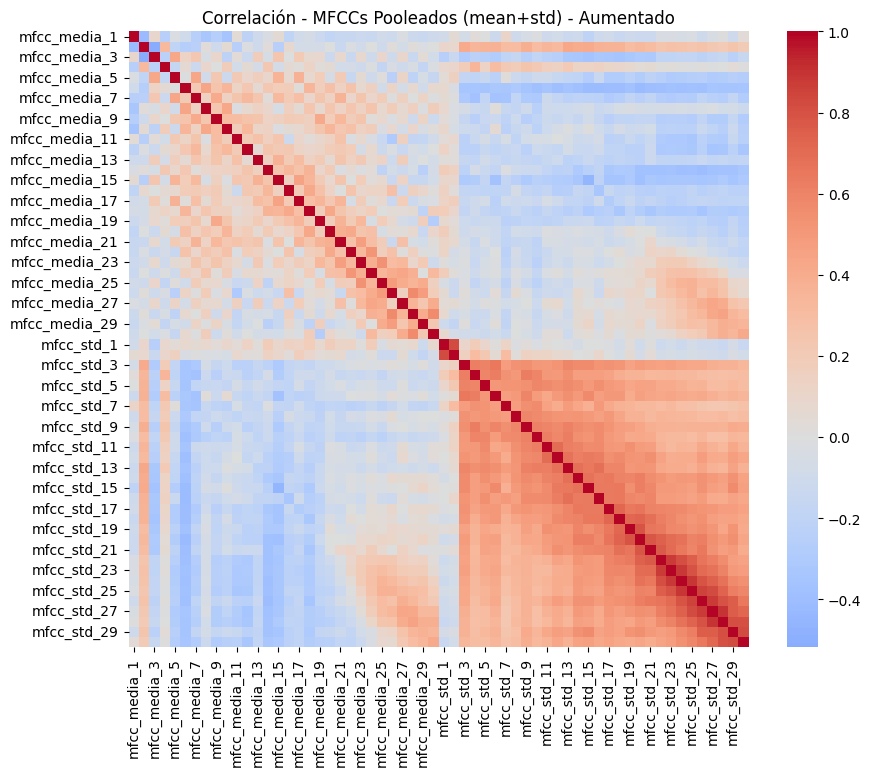

In [24]:
columnas_a_quitar = ['nombre_archivo', 'grupo', 'caja_toracica', 'fold']

X_train = df_train_pool.drop(columns=columnas_a_quitar)

corr_matrix = X_train.corr()

def plot_corr(df, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), cmap='coolwarm', center=0)
    plt.title(f"Correlación - {title}")
    plt.show()

plot_corr(X_train, "MFCCs Pooleados (mean+std) - Aumentado")

In [25]:
columnas_correlacionadas = [f'mfcc_std_{i}' for i in range(1, 31)]
X_correlacionado = X_train[columnas_correlacionadas]

umbral = 0.8
matriz_corr_sub = X_correlacionado.corr()
for i in range(len(matriz_corr_sub.columns)):
    for j in range(i):
        col1 = matriz_corr_sub.columns[i]
        col2 = matriz_corr_sub.columns[j]
        correlacion = matriz_corr_sub.iloc[i, j]
        if correlacion >= umbral:
            print(f"{col1} y {col2} -> Correlación: {correlacion:.3f}")

mfcc_std_2 y mfcc_std_1 -> Correlación: 0.820
mfcc_std_23 y mfcc_std_22 -> Correlación: 0.880
mfcc_std_24 y mfcc_std_22 -> Correlación: 0.814
mfcc_std_24 y mfcc_std_23 -> Correlación: 0.885
mfcc_std_25 y mfcc_std_24 -> Correlación: 0.892
mfcc_std_26 y mfcc_std_25 -> Correlación: 0.854
mfcc_std_27 y mfcc_std_25 -> Correlación: 0.817
mfcc_std_27 y mfcc_std_26 -> Correlación: 0.881
mfcc_std_28 y mfcc_std_27 -> Correlación: 0.894
mfcc_std_29 y mfcc_std_28 -> Correlación: 0.814
mfcc_std_30 y mfcc_std_28 -> Correlación: 0.810
mfcc_std_30 y mfcc_std_29 -> Correlación: 0.823


Con esto podemos ver que hay muchas características que tienen más del 80% de correlación, sin embargo, muy pocas son las que superan el 85% y solo una pareja supera el 90%. En este caso, vamos a eliminar aquellas características que superen el 88% de correlación, tratándose de un valor elevado que nos permite reducir la redundancia entre características altamente correlacionadas sin perder información relevante. De este modo, mantenemos la mayor parte de la varianza del espacio original mientras eliminamos únicamente aquellos pares de características que aportan información prácticamente idéntica al modelo.

In [26]:
umbral = 0.88
pares_a_eliminar = set()

matriz_correlacion = X_train.corr()
for i in range(len(matriz_correlacion.columns)):
    for j in range(i):
        if abs(matriz_correlacion.iloc[i, j]) > umbral:
            col1 = matriz_correlacion.columns[i]
            col2 = matriz_correlacion.columns[j]
            correlacion = matriz_correlacion.iloc[i, j]
            print(f"{col1} y {col2} -> Correlación: {correlacion:.3f}")
            pares_a_eliminar.add(col1)

print("Columnas a eliminar: ")
print(f"{list(pares_a_eliminar)}. Número total = {len(pares_a_eliminar)}")

X_pool_reducido_train = df_train_pool.drop(columns=pares_a_eliminar)
X_pool_reducido_test = df_test_pool.drop(columns=pares_a_eliminar)

mfcc_std_23 y mfcc_std_22 -> Correlación: 0.880
mfcc_std_24 y mfcc_std_23 -> Correlación: 0.885
mfcc_std_25 y mfcc_std_24 -> Correlación: 0.892
mfcc_std_27 y mfcc_std_26 -> Correlación: 0.881
mfcc_std_28 y mfcc_std_27 -> Correlación: 0.894
Columnas a eliminar: 
['mfcc_std_24', 'mfcc_std_27', 'mfcc_std_28', 'mfcc_std_25', 'mfcc_std_23']. Número total = 5


In [27]:
X_pool_reducido_train.head()

,nombre_archivo,grupo,caja_toracica,fold,mfcc_media_1,mfcc_media_2,mfcc_media_3,mfcc_media_4,mfcc_media_5,mfcc_media_6,...,mfcc_std_16,mfcc_std_17,mfcc_std_18,mfcc_std_19,mfcc_std_20,mfcc_std_21,mfcc_std_22,mfcc_std_26,mfcc_std_29,mfcc_std_30
0,Asma con CPAP urgencias_chunk000_original.wav,Ventilación Invasiva,Obstructivo,3,-352.684570,121.787636,6.224621,27.935034,-5.439145,-12.892975,...,9.422900,8.444282,8.405086,7.996205,7.939536,8.150311,8.694556,9.260821,8.406208,8.015336
1,Asma con CPAP urgencias_chunk000_noise.wav,Ventilación Invasiva,Obstructivo,3,-319.231964,91.476944,20.168819,17.385290,0.301241,-14.517222,...,8.852040,7.786160,7.871570,7.761035,7.835503,7.744150,8.473900,8.959689,7.924003,7.678182
2,Asma con CPAP urgencias_chunk000_pitch.wav,Ventilación Invasiva,Obstructivo,3,-374.127502,117.942352,3.405385,23.009096,-14.711658,-15.873027,...,8.166762,10.219102,8.464770,8.474328,9.379764,10.026278,9.859886,8.461644,8.882628,8.779769
3,Asma con CPAP urgencias_chunk000_stretch.wav,Ventilación Invasiva,Obstructivo,3,-331.996765,105.976974,4.271104,23.123810,-3.691541,-13.280165,...,8.910480,8.294790,7.807968,7.688532,7.501404,7.862670,8.152397,7.814078,7.556123,7.301170
4,Asma con CPAP urgencias_chunk001_original.wav,Ventilación Invasiva,Obstructivo,3,-339.487823,123.426231,9.730461,32.741390,3.526648,-13.321842,...,9.115286,8.148713,8.455305,7.836003,7.804312,8.876750,7.445955,7.528830,8.578970,7.592166


In [28]:
X_pool_reducido_test.head()

,nombre_archivo,grupo,caja_toracica,fold,mfcc_media_1,mfcc_media_2,mfcc_media_3,mfcc_media_4,mfcc_media_5,mfcc_media_6,...,mfcc_std_16,mfcc_std_17,mfcc_std_18,mfcc_std_19,mfcc_std_20,mfcc_std_21,mfcc_std_22,mfcc_std_26,mfcc_std_29,mfcc_std_30
0,Asma obesidad grave vni planta_chunk000_origin...,Ventilación Invasiva,Obstructivo,-1,-351.863068,106.542160,4.947843,13.515463,-9.535410,1.731867,...,8.001860,7.343532,7.285684,7.209405,7.575176,7.960977,7.602012,7.451983,7.094824,7.444332
1,Asma obesidad grave vni planta_chunk001_origin...,Ventilación Invasiva,Obstructivo,-1,-393.288605,131.573517,-2.345975,5.945772,-22.507574,3.990155,...,7.270466,7.086808,7.435338,7.038389,7.185234,6.782732,6.558898,7.337729,8.119221,8.108114
2,Asma obesidad grave vni planta_chunk002_origin...,Ventilación Invasiva,Obstructivo,-1,-365.639435,131.818985,-2.072165,16.053932,-15.497279,5.353491,...,7.866225,7.327020,7.831313,7.243642,7.226472,6.781689,6.940420,7.758900,7.901624,7.661132
3,Asma obesidad grave vni planta_chunk003_origin...,Ventilación Invasiva,Obstructivo,-1,-393.031647,130.891052,-3.190361,1.497378,-22.149729,5.697374,...,7.480624,7.620267,7.616788,7.390032,8.201317,7.395317,7.481059,8.124797,7.295523,7.487084
4,Asma obesidad grave vni planta_chunk004_origin...,Ventilación Invasiva,Obstructivo,-1,-388.963470,129.496872,-4.107275,0.907438,-20.780487,6.340427,...,7.960888,7.856251,7.979238,7.489220,7.864351,7.285964,7.486277,8.965296,7.593573,7.646188


En este caso, contamos con un número reducido de características con el que trabajar directamente, por lo que pasaremos al entrenamiento de modelos sin reducción adicional.

#### Entrenamiento de Modelos.

In [35]:
columnas_num = [col for col in X_pool_reducido_train.columns if 'mfcc' in col]

X_train_model = X_pool_reducido_train[columnas_num]
X_test_model = X_pool_reducido_test[columnas_num]

y_train_grupo = df_train_pool['grupo']
y_test_grupo = df_test_pool['grupo']

y_train_caja = df_train_pool['caja_toracica']
y_test_caja = df_test_pool['caja_toracica']

folds_oficiales = df_train_pool['fold'].values
ps = PredefinedSplit(test_fold=folds_oficiales)

def evaluar_modelo_pool(grid_grupo, grid_caja, nombre_modelo):
    print(f"Mejores Hiperparámetros Grupo: {grid_grupo.best_params_}")
    print(f"Mejores Hiperparámetros Caja:  {grid_caja.best_params_}")
    idx_g = grid_grupo.best_index_
    idx_c = grid_caja.best_index_
    acc_g = grid_grupo.cv_results_['mean_test_accuracy'][idx_g]
    f1_mac_g = grid_grupo.cv_results_['mean_test_f1_macro'][idx_g]
    f1_w_g= grid_grupo.cv_results_['mean_test_f1_weighted'][idx_g]
    std_g = grid_grupo.cv_results_['std_test_f1_macro'][idx_g]
    acc_c = grid_caja.cv_results_['mean_test_accuracy'][idx_c]
    f1_mac_c = grid_caja.cv_results_['mean_test_f1_macro'][idx_c]
    f1_w_c= grid_caja.cv_results_['mean_test_f1_weighted'][idx_c]
    std_c = grid_caja.cv_results_['std_test_f1_macro'][idx_c]
    print(f"[CV] Grupo - Acc: {acc_g*100:.2f}% | F1-Macro: {f1_mac_g*100:.2f}% (+/-{std_g*100:.2f}%) | F1-Weighted: {f1_w_g*100:.2f}%")
    print(f"[CV] Caja  - Acc: {acc_c*100:.2f}% | F1-Macro: {f1_mac_c*100:.2f}% (+/-{std_c*100:.2f}%) | F1-Weighted: {f1_w_c*100:.2f}%")
    mlflow.log_metric("grupo_acc_cv",acc_g)
    mlflow.log_metric("grupo_f1_macro_cv",f1_mac_g)
    mlflow.log_metric("grupo_f1_weighted_cv", f1_w_g)
    mlflow.log_metric("caja_acc_cv",acc_c)
    mlflow.log_metric("caja_f1_macro_cv",f1_mac_c)
    mlflow.log_metric("caja_f1_weighted_cv",f1_w_c)
    for key, value in grid_grupo.best_params_.items():
        mlflow.log_param(f"grupo_best_{key}", value)
    for key, value in grid_caja.best_params_.items():
        mlflow.log_param(f"caja_best_{key}", value)

##### Random Forest

In [30]:
param_grid_rf = {
    'n_estimators': [100],
    'max_depth': [None],
    'min_samples_split': [2],
    'min_samples_leaf': [1],
    'max_features': ['sqrt'],
    'bootstrap': [True]
}

with mlflow.start_run(run_name="RF_Chunking_Augmented_pool_Simple_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Augmented_pool") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Simple")
    
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_rf_grupo, grid_rf_caja, "Random Forest - Pool - Aumentado")



Mejores Hiperparámetros Grupo: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros Caja:  {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
[CV] Grupo - Acc: 56.09% | F1-Macro: 23.87% (+/-7.80%) | F1-Weighted: 47.11%
[CV] Caja  - Acc: 46.61% | F1-Macro: 21.95% (+/-8.75%) | F1-Weighted: 38.60%


In [43]:
param_grid_rf_1 = {
    'n_estimators': [100, 150],      
    'max_depth': [None, 10, 20],        
    'min_samples_split': [2, 5],   
    'min_samples_leaf': [1, 2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Augmented_pool_Simple_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Augmented_pool") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Simple")
    
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_rf_grupo, grid_rf_caja, "Random Forest - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 150}
Mejores Hiperparámetros Caja:  {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
[CV] Grupo - Acc: 54.00% | F1-Macro: 28.56% (+/-4.47%) | F1-Weighted: 50.44%
[CV] Caja  - Acc: 46.89% | F1-Macro: 22.52% (+/-7.90%) | F1-Weighted: 38.40%


In [44]:
param_grid_rf_grupo_2_ = {
    'n_estimators': [150, 200, 250],      
    'max_depth': [None, 10],        
    'min_samples_split': [5, 7],   
    'min_samples_leaf': [2, 6],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

param_grid_rf_caja_2 = {
    'n_estimators': [150, 200, 300],      
    'max_depth': [None, 20],        
    'min_samples_split': [2, 5],   
    'min_samples_leaf': [1, 2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}


#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Augmented_pool_Simple_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_Augmented_pool") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Simple")
    
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_grupo_2, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_caja_2, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_rf_grupo, grid_rf_caja, "Random Forest - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 5, 'n_estimators': 200}
Mejores Hiperparámetros Caja:  {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
[CV] Grupo - Acc: 52.85% | F1-Macro: 28.83% (+/-4.58%) | F1-Weighted: 50.63%
[CV] Caja  - Acc: 46.89% | F1-Macro: 22.52% (+/-7.90%) | F1-Weighted: 38.40%


In [45]:
param_grid_rf_final_grupo_pool = {
    'n_estimators': [200],
    'max_depth': [10],
    'min_samples_split': [5],
    'min_samples_leaf': [6],
    'max_features': ['sqrt'],
    'bootstrap': [True]        
}

param_grid_rf_final_caja_pool = {
    'n_estimators': [150],      
    'max_depth': [20],        
    'min_samples_split': [2],   
    'min_samples_leaf': [1],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Augmented_pool_Simple_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_Augmented_pool") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Simple")
    
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_final_grupo_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_final_caja_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_rf_grupo, grid_rf_caja, "Random Forest - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 5, 'n_estimators': 200}
Mejores Hiperparámetros Caja:  {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
[CV] Grupo - Acc: 52.85% | F1-Macro: 28.83% (+/-4.58%) | F1-Weighted: 50.63%
[CV] Caja  - Acc: 46.89% | F1-Macro: 22.52% (+/-7.90%) | F1-Weighted: 38.40%


##### SVM

In [46]:
param_grid_svm = {
    'C': [1.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Augmented_pool_Simple_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Augmented_pool") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Simple")
    
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_svm_grupo, grid_svm_caja, "SVM - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
[CV] Grupo - Acc: 29.41% | F1-Macro: 21.23% (+/-5.04%) | F1-Weighted: 33.92%
[CV] Caja  - Acc: 27.71% | F1-Macro: 16.52% (+/-2.71%) | F1-Weighted: 31.49%


In [47]:
param_grid_svm_1 = {
    'C': [0.5, 1.0, 1.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Augmented_pool_Simple_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Augmented_pool") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Simple")
    
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_svm_grupo, grid_svm_caja, "SVM - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}
[CV] Grupo - Acc: 30.30% | F1-Macro: 21.96% (+/-4.79%) | F1-Weighted: 35.49%
[CV] Caja  - Acc: 26.94% | F1-Macro: 17.08% (+/-3.76%) | F1-Weighted: 31.11%


Rendimiento malo con svm, pasamos directamente a LGBM

##### LightGBM

In [48]:
param_grid_lgbm = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20]
}

with mlflow.start_run(run_name="LGB_Chunking_Augmented_pool_Simple_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Augmented_pool") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Simple")
    
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
Mejores Hiperparámetros Caja:  {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
[CV] Grupo - Acc: 54.52% | F1-Macro: 28.09% (+/-5.58%) | F1-Weighted: 52.62%
[CV] Caja  - Acc: 43.81% | F1-Macro: 22.30% (+/-4.84%) | F1-Weighted: 40.64%


In [49]:
param_grid_lgbm_1 = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63],
    'max_depth': [-1, 10],
    'min_child_samples': [20, 50]
}

with mlflow.start_run(run_name="LGB_Chunking_Augmented_pool_Simple_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Augmented_pool") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Simple")
    
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 31}
Mejores Hiperparámetros Caja:  {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 50, 'n_estimators': 200, 'num_leaves': 31}
[CV] Grupo - Acc: 54.97% | F1-Macro: 30.28% (+/-7.40%) | F1-Weighted: 52.93%
[CV] Caja  - Acc: 44.64% | F1-Macro: 23.75% (+/-5.90%) | F1-Weighted: 41.17%


In [50]:
param_grid_lgbm_2 = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1, 0.15],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20, 50]
}


with mlflow.start_run(run_name="LGB_Chunking_Augmented_pool_Simple_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_Augmented_pool") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Simple")
    
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_2, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_2, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 31}
Mejores Hiperparámetros Caja:  {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 50, 'n_estimators': 200, 'num_leaves': 31}
[CV] Grupo - Acc: 54.97% | F1-Macro: 30.28% (+/-7.40%) | F1-Weighted: 52.93%
[CV] Caja  - Acc: 44.64% | F1-Macro: 23.75% (+/-5.90%) | F1-Weighted: 41.17%


In [51]:
param_grid_lgbm_final_grupo_pool = {
    'n_estimators': [200],
    'learning_rate': [0.05],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20]
}

param_grid_lgbm_final_caja_pool = {
    'n_estimators': [200],
    'learning_rate': [0.1],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [50]
}

with mlflow.start_run(run_name="LGB_Chunking_Augmented_pool_Simple_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_Augmented_pool") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Simple")
    
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_final_grupo_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_final_caja_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - Pool - Aumentado")

Mejores Hiperparámetros Grupo: {'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 31}
Mejores Hiperparámetros Caja:  {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 50, 'n_estimators': 200, 'num_leaves': 31}
[CV] Grupo - Acc: 54.97% | F1-Macro: 30.28% (+/-7.40%) | F1-Weighted: 52.93%
[CV] Caja  - Acc: 44.64% | F1-Macro: 23.75% (+/-5.90%) | F1-Weighted: 41.17%


## Evaluación Final: Test

El rendimiento de los modelos obtenidos en base a este conjunto de datos es inferior al de otros conjuntos de datos, por lo que no haremos test final sobre este conjunto.